# Rate-modulated savings v2 — w_fast headroom + capped multiplier

Fix for the lock-in reopened in `two_layer_rate_modulated_savings.ipynb`: `w_fast` had no
saturation cap, so the rate-modulation multiplier fed an unbounded increment and `w_fast[0]`
ran away to 26+ within the first dominant phase alone. Per Jasper's direct fix:

```
fast_headroom = (w_fast_max - w_fast).clamp(min=0) / w_fast_max
w_fast = w_fast + decay_fast * (1 - w_fast) + increment_fast_effective * retrieval_weights * fast_headroom
```

Plus an **explicit** cap on the modulation multiplier itself (`1 + k*(w_char-1)`), not just
relying on it being indirectly bounded through `w_char_max` — decoupling the two so a change
to `w_char_max` later doesn't silently change how aggressive the rate boost can get.

**What to verify, not assume:**
1. Does `w_fast` actually stay bounded now, including during **phase 1** specifically (that's
   where the runaway happened last time, not phase 4)?
2. Does content-match rate (the diagnostic that actually caught the problem last time) recover
   to something comparable to the un-modulated (`k=0`) baseline?
3. Adding `fast_headroom` changes `w_fast`'s dynamics even at `k=0` (no rate modulation) —
   previously `w_fast` had zero cap at all, just decay-driven self-limiting to ~5.2. Check how
   much the new `k=0`-with-headroom baseline differs from the old uncapped one, so we're not
   silently regressing already-validated results.
4. Do `w_fast_max` and `w_char_max` fight each other — e.g. does a low `w_fast_max` bottleneck
   `w_char`'s own growth (since `w_char`'s consolidation term depends on `(w_fast - 1)`), or
   does a high `w_fast_max` let the lock-in creep back in at higher `k`? Swept across a grid
   rather than committing to `k=0.5` again, since that's exactly what broke last time.

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
torch.manual_seed(42)
n_patterns = 5
dim = 64

X = torch.randn(n_patterns, dim, device=device)
X = F.normalize(X, dim=1)

In [3]:
decay_fast = 0.02
increment_fast = 0.1
decay_char = 0.0005
consolidation_rate = 0.01
char_weight = 1.0
w_char_max = 10.0

def make_update_fn(k, w_fast_max, max_multiplier=3.0):
    def update_two_layer(w_fast, w_char, retrieval_weights):
        multiplier = (1 + k * (w_char - 1)).clamp(max=max_multiplier)
        increment_fast_effective = increment_fast * multiplier
        fast_headroom = (w_fast_max - w_fast).clamp(min=0) / w_fast_max
        w_fast = w_fast + decay_fast * (1 - w_fast) + increment_fast_effective * retrieval_weights * fast_headroom

        char_headroom = (w_char_max - w_char).clamp(min=0) / w_char_max
        w_char = w_char + decay_char * (1 - w_char) + consolidation_rate * (w_fast - 1).clamp(min=0) * char_headroom
        return w_fast, w_char
    return update_two_layer

def retrieve_two_layer(query, X, w_fast, w_char, beta=4.0):
    similarities = X @ query
    biased = beta * similarities + torch.log(w_fast) + char_weight * torch.log(w_char)
    weights = F.softmax(biased, dim=0)
    retrieved = X.T @ weights
    return retrieved, weights

def run_two_layer_experiment(k, w_fast_max, phase_len, phase_patterns, seed=0, dominant_prob=0.7, max_multiplier=3.0):
    update_two_layer = make_update_fn(k, w_fast_max, max_multiplier)
    n_phases = len(phase_patterns)
    n_steps = phase_len * n_phases

    w_fast = torch.ones(n_patterns, device=device)
    w_char = torch.ones(n_patterns, device=device)
    fast_history = torch.zeros(n_steps, n_patterns)
    char_history = torch.zeros(n_steps, n_patterns)
    queried_idx_history = torch.zeros(n_steps, dtype=torch.long)
    won_idx_history = torch.zeros(n_steps, dtype=torch.long)

    minor_prob = (1 - dominant_prob) / (n_patterns - 1)

    torch.manual_seed(seed)
    for step in range(n_steps):
        phase = step // phase_len
        dom = phase_patterns[phase]
        probs = torch.full((n_patterns,), minor_prob)
        probs[dom] = dominant_prob

        idx = torch.multinomial(probs, 1).item()
        query = F.normalize(X[idx] + torch.randn(dim, device=device) * 0.3, dim=0)

        retrieved, retrieval_weights = retrieve_two_layer(query, X, w_fast, w_char, beta=4.0)
        w_fast, w_char = update_two_layer(w_fast, w_char, retrieval_weights)

        fast_history[step] = w_fast
        char_history[step] = w_char
        queried_idx_history[step] = idx
        won_idx_history[step] = retrieval_weights.argmax()

    phase_bounds = [i * phase_len for i in range(n_phases + 1)]
    return {"fast": fast_history, "char": char_history, "queried": queried_idx_history,
            "won": won_idx_history, "phase_bounds": phase_bounds}

## Step 1 — does the fix contain phase 1 (where the runaway actually happened)?

Run `k=0` (new baseline, now with `fast_headroom` even though no rate modulation is active)
and `k=0.5` (the value that broke last time) with `w_fast_max=10.0` (matching `w_char_max`,
first-pass default) and `max_multiplier=3.0`.

In [4]:
phase_patterns = [0, 1, 2, 0, 3]
w_fast_max_default = 10.0

run_k0 = run_two_layer_experiment(k=0.0, w_fast_max=w_fast_max_default, phase_len=400, phase_patterns=phase_patterns, seed=0)
run_k05 = run_two_layer_experiment(k=0.5, w_fast_max=w_fast_max_default, phase_len=400, phase_patterns=phase_patterns, seed=0)
pb = run_k0["phase_bounds"]

print("k=0 (new baseline, w_fast_max=10): final w_fast =", run_k0["fast"][-1])
print("k=0 (new baseline, w_fast_max=10): final w_char =", run_k0["char"][-1])
print("k=0.5 (test, w_fast_max=10):       final w_fast =", run_k05["fast"][-1])
print("k=0.5 (test, w_fast_max=10):       final w_char =", run_k05["char"][-1])

print("\nPhase-1 (first dominant phase) peak w_fast[0] -- this is where the runaway fired last time:")
print(f"  k=0:   {run_k0['fast'][pb[0]:pb[1], 0].max().item():.3f}")
print(f"  k=0.5: {run_k05['fast'][pb[0]:pb[1], 0].max().item():.3f}")

k=0 (new baseline, w_fast_max=10): final w_fast = tensor([1.5866, 1.6741, 1.5011, 2.8332, 1.3243])
k=0 (new baseline, w_fast_max=10): final w_char = tensor([7.2166, 5.9544, 5.7339, 5.8044, 4.1136])
k=0.5 (test, w_fast_max=10):       final w_fast = tensor([2.3666, 2.8966, 2.3635, 5.0720, 1.5863])
k=0.5 (test, w_fast_max=10):       final w_char = tensor([8.4294, 8.1531, 7.7774, 7.5950, 4.7551])

Phase-1 (first dominant phase) peak w_fast[0] -- this is where the runaway fired last time:
  k=0:   3.523
  k=0.5: 6.153


## Step 2 — content-match diagnostic (the check that actually caught the problem last time)

Compare against the previously-recorded baseline numbers from the v1 notebook (no
`fast_headroom` at all): k=0 content-match was `81.2/44.7/78.0/81.7/86.0%` across phases 1-5,
and k=0.5 (broken) was `78.8/7.8/6.2/67.0/9.3%`.

In [5]:
def content_match_report(run, phase_patterns, label):
    pb = run["phase_bounds"]
    print(label + ":")
    rates = []
    for p, dom in enumerate(phase_patterns):
        lo, hi = pb[p], pb[p + 1]
        q = run["queried"][lo:hi]
        w = run["won"][lo:hi]
        match_rate = (q == w).float().mean().item()
        rates.append(match_rate)
        print(f"  phase {p+1} (dominant=pattern {dom}): content-match rate = {match_rate*100:.1f}%")
    return rates

rates_k0 = content_match_report(run_k0, phase_patterns, "k=0 (new baseline, w_fast_max=10)")
rates_k05 = content_match_report(run_k05, phase_patterns, "k=0.5 (test, w_fast_max=10)")

k=0 (new baseline, w_fast_max=10):
  phase 1 (dominant=pattern 0): content-match rate = 86.5%
  phase 2 (dominant=pattern 1): content-match rate = 72.5%
  phase 3 (dominant=pattern 2): content-match rate = 87.7%
  phase 4 (dominant=pattern 0): content-match rate = 89.5%
  phase 5 (dominant=pattern 3): content-match rate = 94.2%
k=0.5 (test, w_fast_max=10):
  phase 1 (dominant=pattern 0): content-match rate = 81.2%
  phase 2 (dominant=pattern 1): content-match rate = 40.3%
  phase 3 (dominant=pattern 2): content-match rate = 69.2%
  phase 4 (dominant=pattern 0): content-match rate = 82.5%
  phase 5 (dominant=pattern 3): content-match rate = 82.0%


## Step 3 — ordering/monopolization check, on both w_char AND w_fast this time

Last time the `w_char` ordering check alone didn't catch the problem (ratio 3.14, under the
5x threshold) because the runaway was in `w_fast`, which had no check at all. Checking both
layers now.

In [6]:
def ordering_check(history, label, layer_name):
    final_vals = history[-1]
    sorted_vals, sorted_idx = torch.sort(final_vals, descending=True)
    ratio = (sorted_vals[0] / sorted_vals[1]).item()
    print(f"{label} [{layer_name}]: final = {[round(v, 2) for v in final_vals.tolist()]}")
    print(f"  order (high->low) = {sorted_idx.tolist()}, top/second ratio = {ratio:.2f}, "
          f"monopolized = {ratio > 5.0}")

ordering_check(run_k0["char"], "k=0", "w_char")
ordering_check(run_k0["fast"], "k=0", "w_fast")
ordering_check(run_k05["char"], "k=0.5", "w_char")
ordering_check(run_k05["fast"], "k=0.5", "w_fast")

k=0 [w_char]: final = [7.22, 5.95, 5.73, 5.8, 4.11]
  order (high->low) = [0, 1, 3, 2, 4], top/second ratio = 1.21, monopolized = False
k=0 [w_fast]: final = [1.59, 1.67, 1.5, 2.83, 1.32]
  order (high->low) = [3, 1, 0, 2, 4], top/second ratio = 1.69, monopolized = False
k=0.5 [w_char]: final = [8.43, 8.15, 7.78, 7.6, 4.76]
  order (high->low) = [0, 1, 2, 3, 4], top/second ratio = 1.03, monopolized = False
k=0.5 [w_fast]: final = [2.37, 2.9, 2.36, 5.07, 1.59]
  order (high->low) = [3, 1, 0, 2, 4], top/second ratio = 1.75, monopolized = False


## Step 4 — savings slope comparison (phase 1 vs phase 4 vs phase 5), same methodology throughout

In [7]:
def climb_stats(fast_history, pattern_idx, phase_start, phase_end, label, verbose=True):
    segment = fast_history[phase_start:phase_end, pattern_idx].numpy()
    start_val = segment[0]
    peak_val = segment.max()
    net_increase = peak_val - start_val

    kernel = np.ones(10) / 10
    smoothed = np.convolve(segment, kernel, mode="valid")
    threshold = start_val + 0.9 * net_increase
    hits = np.nonzero(smoothed >= threshold)[0]
    steps_to_90pct = int(hits[0]) if len(hits) > 0 else None

    x = np.arange(50)
    slope, intercept = np.polyfit(x, segment[:50], 1)

    if verbose:
        print(f"{label}: start={start_val:.3f} peak={peak_val:.3f} net_increase={net_increase:.3f} "
              f"steps_to_90%={steps_to_90pct} initial_slope(50 steps)={slope:.4f}")
    return {"start": start_val, "peak": peak_val, "net_increase": net_increase,
            "steps_to_90pct": steps_to_90pct, "slope": slope, "segment": segment}

print("--- k=0 (new baseline, w_fast_max=10) ---")
r_k0_p1 = climb_stats(run_k0["fast"], 0, pb[0], pb[1], "phase 1, pattern 0 (cold start)")
r_k0_p4 = climb_stats(run_k0["fast"], 0, pb[3], pb[4], "phase 4, pattern 0 (return)")
r_k0_p5 = climb_stats(run_k0["fast"], 3, pb[4], pb[5], "phase 5, pattern 3 (cross-pattern control)")

print()
print("--- k=0.5 (test, w_fast_max=10) ---")
r_k05_p1 = climb_stats(run_k05["fast"], 0, pb[0], pb[1], "phase 1, pattern 0 (cold start)")
r_k05_p4 = climb_stats(run_k05["fast"], 0, pb[3], pb[4], "phase 4, pattern 0 (return)")
r_k05_p5 = climb_stats(run_k05["fast"], 3, pb[4], pb[5], "phase 5, pattern 3 (cross-pattern control)")

print()
print(f"k=0.5: phase4 slope ({r_k05_p4['slope']:.4f}) > phase1 slope ({r_k05_p1['slope']:.4f})? "
      f"{r_k05_p4['slope'] > r_k05_p1['slope']}")
print(f"k=0.5: phase4 slope ({r_k05_p4['slope']:.4f}) > phase5 slope ({r_k05_p5['slope']:.4f})? "
      f"{r_k05_p4['slope'] > r_k05_p5['slope']}")

--- k=0 (new baseline, w_fast_max=10) ---
phase 1, pattern 0 (cold start): start=1.013 peak=3.523 net_increase=2.510 steps_to_90%=166 initial_slope(50 steps)=0.0282
phase 4, pattern 0 (return): start=1.781 peak=3.182 net_increase=1.401 steps_to_90%=104 initial_slope(50 steps)=0.0148
phase 5, pattern 3 (cross-pattern control): start=1.365 peak=2.866 net_increase=1.501 steps_to_90%=298 initial_slope(50 steps)=0.0111

--- k=0.5 (test, w_fast_max=10) ---
phase 1, pattern 0 (cold start): start=1.013 peak=6.153 net_increase=5.139 steps_to_90%=213 initial_slope(50 steps)=0.0302
phase 4, pattern 0 (return): start=3.122 peak=5.539 net_increase=2.416 steps_to_90%=68 initial_slope(50 steps)=0.0321
phase 5, pattern 3 (cross-pattern control): start=1.567 peak=5.144 net_increase=3.576 steps_to_90%=287 initial_slope(50 steps)=0.0208

k=0.5: phase4 slope (0.0321) > phase1 slope (0.0302)? True
k=0.5: phase4 slope (0.0321) > phase5 slope (0.0208)? True


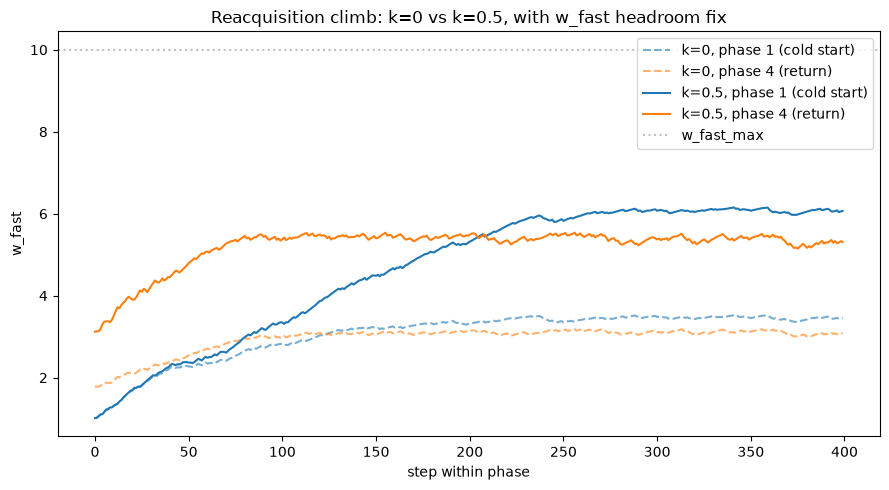

In [8]:
plt.figure(figsize=(9, 5))
plt.plot(r_k0_p1["segment"], '--', color='tab:blue', alpha=0.6, label="k=0, phase 1 (cold start)")
plt.plot(r_k0_p4["segment"], '--', color='tab:orange', alpha=0.6, label="k=0, phase 4 (return)")
plt.plot(r_k05_p1["segment"], color='tab:blue', label="k=0.5, phase 1 (cold start)")
plt.plot(r_k05_p4["segment"], color='tab:orange', label="k=0.5, phase 4 (return)")
plt.axhline(y=w_fast_max_default, color='gray', linestyle=':', alpha=0.5, label='w_fast_max')
plt.xlabel("step within phase")
plt.ylabel("w_fast")
plt.title("Reacquisition climb: k=0 vs k=0.5, with w_fast headroom fix")
plt.legend()
plt.tight_layout()
plt.savefig("savings_v2_comparison.png", dpi=100)
plt.show()

## Step 5 — sweep k x w_fast_max, check for interaction effects

Grid: `k` in {0.25, 0.5, 1.0} x `w_fast_max` in {5, 10, 20}, fixed `w_char_max=10`,
`consolidation_rate=0.01`, `max_multiplier=3.0`. For each combination: ordering/monopolization
on both layers, content-match rate (worst phase, i.e. the most sensitive lock-in indicator),
and whether genuine savings holds (phase-4 raw slope > phase-1 raw slope).

Specifically watching for the interaction risk: does a **low** `w_fast_max` bottleneck
`w_char`'s own growth (since `w_char`'s consolidation term depends directly on
`(w_fast - 1)`, so capping `w_fast` low could starve `w_char` of the signal it needs to grow
at all)? Does a **high** `w_fast_max` combined with high `k` let content-match degrade again?

In [9]:
k_grid = [0.25, 0.5, 1.0]
w_fast_max_grid = [5.0, 10.0, 20.0]

sweep_results = {}
for k in k_grid:
    for wfm in w_fast_max_grid:
        run = run_two_layer_experiment(k=k, w_fast_max=wfm, phase_len=400, phase_patterns=phase_patterns, seed=0)
        sweep_results[(k, wfm)] = run

print(f"Ran {len(sweep_results)} combinations.")

Ran 9 combinations.


In [10]:
def summarize(run, phase_patterns):
    pbl = run["phase_bounds"]
    match_rates = []
    for p, dom in enumerate(phase_patterns):
        lo, hi = pbl[p], pbl[p + 1]
        q = run["queried"][lo:hi]
        w = run["won"][lo:hi]
        match_rates.append((q == w).float().mean().item())

    final_char = run["char"][-1]
    final_fast = run["fast"][-1]
    char_sorted, _ = torch.sort(final_char, descending=True)
    fast_sorted, _ = torch.sort(final_fast, descending=True)
    char_ratio = (char_sorted[0] / char_sorted[1]).item()
    fast_ratio = (fast_sorted[0] / fast_sorted[1]).item()

    r_p1 = climb_stats(run["fast"], 0, pbl[0], pbl[1], "", verbose=False)
    r_p4 = climb_stats(run["fast"], 0, pbl[3], pbl[4], "", verbose=False)
    savings_real = r_p4["slope"] > r_p1["slope"]

    return {
        "min_match_rate": min(match_rates), "match_rates": match_rates,
        "char_ratio": char_ratio, "fast_ratio": fast_ratio,
        "char_monopolized": char_ratio > 5.0, "fast_monopolized": fast_ratio > 5.0,
        "p1_slope": r_p1["slope"], "p4_slope": r_p4["slope"], "savings_real": savings_real,
        "char_peak_pattern1_own_phase": run["char"][pbl[1]:pbl[2], 1].max().item(),
        "fast_peak": final_fast.max().item(),
    }

print(f"{'k':>5} {'w_fast_max':>11} {'min_match%':>11} {'char_ratio':>11} {'fast_ratio':>11} "
      f"{'p1_slope':>9} {'p4_slope':>9} {'savings':>8} {'pat1_char_peak':>15}")
for k in k_grid:
    for wfm in w_fast_max_grid:
        s = summarize(sweep_results[(k, wfm)], phase_patterns)
        print(f"{k:>5} {wfm:>11} {s['min_match_rate']*100:>10.1f}% {s['char_ratio']:>11.2f} "
              f"{s['fast_ratio']:>11.2f} {s['p1_slope']:>9.4f} {s['p4_slope']:>9.4f} "
              f"{str(s['savings_real']):>8} {s['char_peak_pattern1_own_phase']:>15.2f}")

    k  w_fast_max  min_match%  char_ratio  fast_ratio  p1_slope  p4_slope  savings  pat1_char_peak
 0.25         5.0       70.5%        1.10        1.33    0.0226    0.0151    False            5.07
 0.25        10.0       34.3%        1.08        1.33    0.0292    0.0267    False            5.13
 0.25        20.0       13.2%        1.22        1.57    0.0331    0.0331    False            4.07
  0.5         5.0       68.8%        1.05        1.44    0.0232    0.0165    False            5.64
  0.5        10.0       40.3%        1.03        1.75    0.0302    0.0321     True            6.14
  0.5        20.0       21.0%        1.03        1.94    0.0343    0.0434     True            5.22
  1.0         5.0       79.8%        1.04        1.48    0.0244    0.0179    False            6.12
  1.0        10.0       54.3%        1.02        1.93    0.0321    0.0343     True            7.05
  1.0        20.0       37.7%        1.02        2.48    0.0369    0.0474     True            7.05


## Interaction check — does low w_fast_max bottleneck w_char growth?

Pattern 1's own `w_char` peak (during its own dominant phase 2) is the direct signal: if a
low `w_fast_max` starves `w_char`'s consolidation input, this peak should drop noticeably at
`w_fast_max=5` vs `w_fast_max=20`, independent of `k`.

In [11]:
print("Pattern 1's own w_char peak (phase 2) by w_fast_max, averaged over k:")
for wfm in w_fast_max_grid:
    peaks = [summarize(sweep_results[(k, wfm)], phase_patterns)["char_peak_pattern1_own_phase"] for k in k_grid]
    print(f"  w_fast_max={wfm}: peaks across k={k_grid} -> {[round(p, 2) for p in peaks]}, mean={np.mean(peaks):.2f}")

Pattern 1's own w_char peak (phase 2) by w_fast_max, averaged over k:
  w_fast_max=5.0: peaks across k=[0.25, 0.5, 1.0] -> [5.07, 5.64, 6.12], mean=5.61
  w_fast_max=10.0: peaks across k=[0.25, 0.5, 1.0] -> [5.13, 6.14, 7.05], mean=6.11
  w_fast_max=20.0: peaks across k=[0.25, 0.5, 1.0] -> [4.07, 5.22, 7.05], mean=5.45


## Verdict

In [12]:
any_monopolized = False
any_savings_absent = False
for k in k_grid:
    for wfm in w_fast_max_grid:
        s = summarize(sweep_results[(k, wfm)], phase_patterns)
        if s["char_monopolized"] or s["fast_monopolized"]:
            any_monopolized = True
            print(f"MONOPOLIZATION at k={k}, w_fast_max={wfm}: char_ratio={s['char_ratio']:.2f}, fast_ratio={s['fast_ratio']:.2f}")
        if not s["savings_real"]:
            any_savings_absent = True
            print(f"NO SAVINGS at k={k}, w_fast_max={wfm}: p1_slope={s['p1_slope']:.4f}, p4_slope={s['p4_slope']:.4f}")

print(f"\nAny monopolization across the grid: {any_monopolized}")
print(f"Any combination without genuine savings: {any_savings_absent}")

NO SAVINGS at k=0.25, w_fast_max=5.0: p1_slope=0.0226, p4_slope=0.0151
NO SAVINGS at k=0.25, w_fast_max=10.0: p1_slope=0.0292, p4_slope=0.0267
NO SAVINGS at k=0.25, w_fast_max=20.0: p1_slope=0.0331, p4_slope=0.0331
NO SAVINGS at k=0.5, w_fast_max=5.0: p1_slope=0.0232, p4_slope=0.0165
NO SAVINGS at k=1.0, w_fast_max=5.0: p1_slope=0.0244, p4_slope=0.0179

Any monopolization across the grid: False
Any combination without genuine savings: True
